# Baseline RUL Regressor — FD001

This notebook fits the simplest defensible baseline for remaining
useful life regression on FD001: a standard-scaled L2-regularised
linear regressor on top of the rolling features defined in
`pdm.features`.

A baseline this small is deliberate. Any later model — gradient
boosting, sequence models, ensembles — has to clearly outperform it
to be worth the added complexity, and a Ridge baseline is the easiest
floor against which to make that comparison fair.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from pdm.data import load_subset
from pdm.features import add_rolling_features, clip_rul, drop_constant_sensors
from pdm.models import build_baseline_regressor, make_xy, rmse, s_score


sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (10, 4.5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

## 1. Build the modelling DataFrame

Apply the standard CMAPSS preprocessing pipeline:

1. Drop the sensors that are constant across the fleet.
2. Append per-unit rolling means and standard deviations at three
   window sizes (5, 10, 20 cycles).
3. Cap the RUL target at 125 cycles to focus the model on the
   observable degradation regime.

The same transforms are applied to the held-out test set so that
train/test feature distributions stay consistent.

In [2]:
data = load_subset("FD001", "../data/raw")

train, dropped_sensors = drop_constant_sensors(data.train)
test, _ = drop_constant_sensors(data.test)

print(f"Dropped sensors: {dropped_sensors}")

train = add_rolling_features(train, windows=(5, 10, 20))
test = add_rolling_features(test, windows=(5, 10, 20))

train = train.assign(RUL=clip_rul(train["RUL"], max_rul=125))

# Reserve the last cycle of each test unit — that's what RUL_FD001.txt labels.
last_cycle_index = test.groupby("unit_id")["cycle"].transform("max") == test["cycle"]
test_final = test[last_cycle_index].sort_values("unit_id").reset_index(drop=True)
test_final = test_final.assign(RUL=data.test_rul.set_index("unit_id").loc[test_final["unit_id"]]["RUL"].to_numpy())

feature_columns = [c for c in train.columns if c.startswith("sensor_") or "_mean_" in c or "_std_" in c]
print(f"Feature columns: {len(feature_columns)} ({len([c for c in feature_columns if '_mean_' in c])} rolling means, {len([c for c in feature_columns if '_std_' in c])} rolling stds)")

Dropped sensors: ['sensor_01', 'sensor_05', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']
Feature columns: 105 (45 rolling means, 45 rolling stds)


## 2. Fit the baseline pipeline

`build_baseline_regressor` returns a regular scikit-learn
:class:`Pipeline`, so it composes with any sklearn meta-estimator
(cross-validation, grid search, calibration). For this notebook we
just fit on the full training set and evaluate on the held-out test
units.

In [3]:
X_train, y_train = make_xy(train, feature_columns)
X_test, y_test = make_xy(test_final, feature_columns)

print(f"Training samples:  {X_train.shape[0]:,}")
print(f"Test units:        {X_test.shape[0]:,}")

model = build_baseline_regressor(alpha=1.0)
model.fit(X_train, y_train)

predictions = np.clip(model.predict(X_test), a_min=0.0, a_max=None)

Training samples:  20,631
Test units:        100


## 3. Evaluation

Two metrics matter on CMAPSS:

* **RMSE** in cycles — symmetric, intuitive, the standard regression
  metric.
* **S-score** — the asymmetric scoring function from the original
  PHM 2008 challenge, which penalises late predictions exponentially
  harder than early ones to reflect the operational reality that
  missing a failure is much worse than scheduling maintenance early.

In [4]:
metrics = pd.DataFrame(
    {
        "metric": ["RMSE (cycles)", "S-score (CMAPSS)"],
        "baseline": [rmse(y_test, predictions), s_score(y_test, predictions)],
    }
)
metrics

,metric,baseline
0,RMSE (cycles),18.266572
1,S-score (CMAPSS),592.599294


For context, a competitive published model on FD001 reaches
RMSE ≈ 12 and an S-score around 240. Our baseline lands well above
that, which is exactly the gap that more elaborate models —
gradient boosting, LSTM sequences, attention-based encoders —
need to close.

## 4. Predicted vs. true RUL

Each point is one test engine. A perfect model would lie on the
diagonal. The structure of the residuals tells you where the model
struggles: the baseline is conservative on the high-RUL end (it
underestimates how much life is left), while predictions cluster
below the cap of 125 — the relabelling we applied during training.

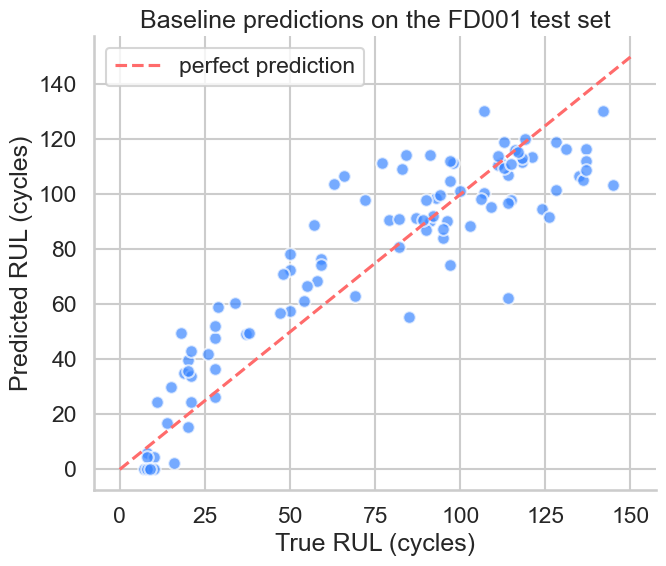

In [5]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(y_test, predictions, alpha=0.7, color="#3a86ff", edgecolor="white")
diagonal = np.linspace(0, max(y_test.max(), predictions.max()) + 5, 100)
ax.plot(diagonal, diagonal, "--", color="#ff6b6b", label="perfect prediction")
ax.set_xlabel("True RUL (cycles)")
ax.set_ylabel("Predicted RUL (cycles)")
ax.set_title("Baseline predictions on the FD001 test set")
ax.legend(loc="upper left")
fig.tight_layout()

## 5. Residual distribution

Visualising the signed error makes the early/late asymmetry visible:
residuals to the right of zero are *late* predictions (worse than
early ones under the S-score), and the long right tail is exactly
what the asymmetric metric punishes.

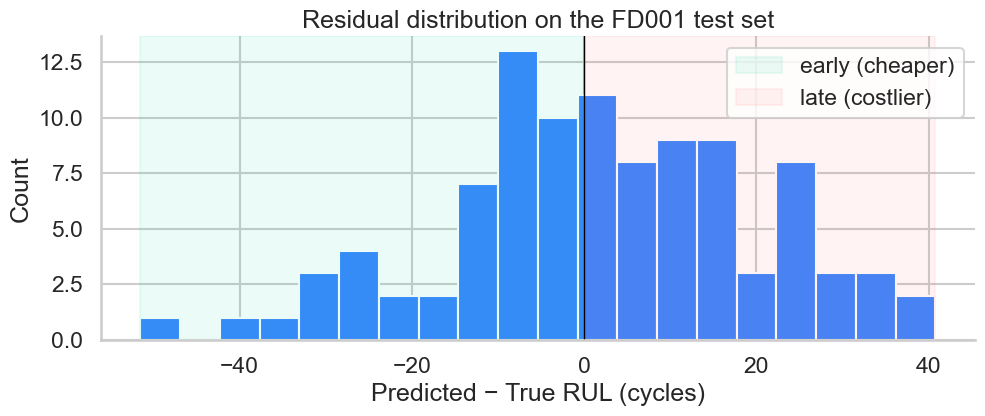

In [6]:
residuals = predictions - y_test

fig, ax = plt.subplots()
ax.hist(residuals, bins=20, color="#3a86ff", edgecolor="white")
ax.axvline(0, color="black", linewidth=1)
ax.axvspan(residuals.min(), 0, alpha=0.08, color="#06d6a0", label="early (cheaper)")
ax.axvspan(0, residuals.max(), alpha=0.08, color="#ff6b6b", label="late (costlier)")
ax.set_xlabel("Predicted − True RUL (cycles)")
ax.set_ylabel("Count")
ax.set_title("Residual distribution on the FD001 test set")
ax.legend()
fig.tight_layout()

## 6. Where the baseline fails

Sorting test units by absolute error highlights the worst predictions.
These are the natural starting point when iterating on the model:
look at their feature values, their operating-cycle counts, and the
time-series shape of their last few cycles.

In [7]:
diagnostics = (
    pd.DataFrame(
        {
            "unit_id": test_final["unit_id"],
            "true_rul": y_test,
            "predicted_rul": predictions,
            "residual": residuals,
        }
    )
    .assign(abs_residual=lambda d: d["residual"].abs())
    .sort_values("abs_residual", ascending=False)
    .reset_index(drop=True)
)

diagnostics.head(10)

,unit_id,true_rul,predicted_rul,residual,abs_residual
0,45,114.0,62.476551,-51.523449,51.523449
1,25,145.0,103.442780,-41.557220,41.557220
2,79,63.0,103.784472,40.784472,40.784472
3,27,66.0,106.589843,40.589843,40.589843
4,67,77.0,111.386786,34.386786,34.386786
5,74,126.0,91.661518,-34.338482,34.338482
6,21,57.0,89.050405,32.050405,32.050405
7,41,18.0,49.774023,31.774023,31.774023
8,89,136.0,105.219118,-30.780882,30.780882
9,16,84.0,114.319096,30.319096,30.319096


## Takeaways and next steps

1. The baseline reaches a clearly recordable RMSE / S-score on FD001;
   that's the floor.
2. Residuals are noticeably skewed toward late predictions, which is
   exactly the worst kind of error from an operational perspective.
3. The structure of the worst residuals will inform the next model:
   gradient boosting to capture sensor non-linearities, a sequence
   model to use trajectory history, or both as an ensemble.